# SIMBAC-NFS — Interactive Demo

This notebook runs **SIMBAC-NFS** end-to-end on the **Combined Cycle Power Plant (CCPP)** dataset
([UCI ID 294](https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant)) —
9568 samples, 4 features, predicting net hourly electrical energy output (PE, in MW).

Power Plant is one of the most compressible datasets in the paper:
SIMBAC-NFS reduces the full pool of ~300 rules down to **~8 rules** (~97.6% compression)
while maintaining competitive prediction accuracy.

This demo uses the **exact same protocol as the paper**:
- 5-fold outer cross-validation
- 3-fold inner CV to select the rule budget `nc` from {15, 20, 25}
- Gradient-boosted pool (T=5 rounds × M=3 FCM-TSK bags)
- SIMBA compression (τ=0.95, CI=0.99)

> **Runtime:** ~5–10 minutes on a laptop (9568 samples).

> **Dependency note:** Data is downloaded directly from UCI as a ZIP containing an Excel file.
> The `openpyxl` package is required (`pip install openpyxl`) in addition to the standard dependencies.

In [ ]:
%pip install openpyxl


## 1. Imports

In [1]:
import sys
import io
import zipfile
import urllib.request
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

sys.path.insert(0, ".")

from src.models.pool import FCMTSKPool, select_features_mi
from src.models.compression import SIMBACCompressor

print("Imports OK")

Warning! PyTorch package is not installed, this package must be installed when you need to use pytsk.gradient_descent
Imports OK


## 2. Load Data

**Combined Cycle Power Plant** — 9568 samples, 4 features.
Predicts net hourly electrical energy output (PE, MW) from ambient temperature (AT),
exhaust vacuum (V), ambient pressure (AP), and relative humidity (RH).

In [2]:
URL = "https://archive.ics.uci.edu/static/public/294/combined+cycle+power+plant.zip"

print("Downloading Power Plant dataset from UCI...")
with urllib.request.urlopen(URL) as resp:
    zip_bytes = resp.read()

with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
    xlsx_files = [n for n in zf.namelist() if n.endswith(".xlsx")]
    with zf.open(xlsx_files[0]) as f:
        df = pd.read_excel(f, engine="openpyxl")

feature_names = ["AT", "V", "AP", "RH"]
target_name   = "PE"

# Rename columns to match standard names if needed
df.columns = feature_names + [target_name]

X = df[feature_names].values.astype(float)
y = df[target_name].values.astype(float)

print(f"Samples : {len(X)}")
print(f"Features: {feature_names}")
print(f"Target  : {target_name}  [{y.min():.2f}, {y.max():.2f}] MW")

Samples : 9568
Features: ['AT', 'V', 'AP', 'RH']
Target  : PE  [420.26, 495.76] MW


## 3. Hyperparameters

These are the exact values from the paper for the Power Plant dataset (D4).

In [3]:
# Architecture
T               = 5             # boosting rounds
M               = 3             # FCM-TSK bags per round
tau             = 0.95          # rule-merging threshold
bootstrap_ratio = 1.0           # bootstrap sample fraction

# Training
lr                    = 0.3     # boosting learning rate
ci                    = 0.99    # cumulative-importance cutoff
min_cluster_importance= 0.0     # per-cluster importance floor
min_rules             = 3       # minimum rules after compression
max_feat              = 7       # MI feature-selection cap
seed                  = 42

# Inner-CV grids
nrules_grid = [15, 20, 25]
alpha_grid  = [1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0, 100.0, 1e3, 1e4]

print("Hyperparameters set.")

Hyperparameters set.


## 4. Helper Functions

In [4]:
rmse_fn = lambda a, b: float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))
mae_fn  = lambda a, b: float(np.mean(np.abs(np.asarray(a) - np.asarray(b))))
r2_fn   = lambda a, b: float(1 - np.sum((np.asarray(a) - np.asarray(b)) ** 2)
                              / (np.sum((np.asarray(a) - np.mean(a)) ** 2) + 1e-12))


def fit_pool(X_tr, y_tr, nc, X_eval=None):
    """Build gradient-boosted pool. Returns (pool, pool_pred_eval).
    pool_pred_eval is the GB ensemble prediction on X_eval (for fidelity).
    """
    y_res = y_tr.copy().astype(float)
    pool  = []
    pool_pred_eval = np.zeros(len(X_eval)) if X_eval is not None else None

    for t in range(T):
        bag = FCMTSKPool(
            n_estimators=M, n_rules=nc, min_rules=min_rules,
            bootstrap_ratio=bootstrap_ratio,
            base_params={"mf_type": "gaussian"},
            random_state=seed + t,
        )
        bag.fit(X_tr, y_res)
        round_pred_tr = lr * np.mean([e.predict(X_tr) for e in bag.estimators_], axis=0)
        y_res -= round_pred_tr
        if X_eval is not None:
            pool_pred_eval += lr * np.mean([e.predict(X_eval) for e in bag.estimators_], axis=0)
        pool.extend(bag.estimators_)
    return pool, pool_pred_eval


def inner_cv_select(X_tr, y_tr, inner_splits):
    best_nc, best_score = nrules_grid[0], np.inf
    for nc in nrules_grid:
        scores = []
        for i_tr, i_te in inner_splits:
            try:
                pool, _ = fit_pool(X_tr[i_tr], y_tr[i_tr], nc)
                comp = SIMBACCompressor(
                    tau=tau, weight_by_performance=True,
                    cumulative_importance=ci,
                    min_cluster_importance=min_cluster_importance,
                    min_rules=min_rules,
                    refit_consequents=True, tune_refit_alpha=True,
                    refit_alpha_grid=alpha_grid,
                )
                cm = comp.compress(pool, X_tr[i_tr], y_tr[i_tr])
                scores.append(rmse_fn(y_tr[i_te], cm.predict(X_tr[i_te])))
            except Exception:
                scores.append(np.inf)
        s = float(np.nanmean(scores)) if scores else np.inf
        if s < best_score:
            best_score, best_nc = s, nc
    return best_nc


def compute_pairwise_dist(centers):
    """Mean pairwise L2 distance between rule centers (normalized to [0,1]^d)."""
    n = len(centers)
    if n < 2:
        return 0.0
    dists = []
    for i in range(n):
        for j in range(i + 1, n):
            dists.append(float(np.linalg.norm(centers[i] - centers[j])))
    return float(np.mean(dists))


def compute_fidelity(pool_pred, model_pred):
    """R² of compressed model predictions vs gradient-boosted pool predictions."""
    p = np.asarray(pool_pred, dtype=float)
    m = np.asarray(model_pred, dtype=float)
    ss_tot = np.sum((p - p.mean()) ** 2) + 1e-12
    ss_res = np.sum((p - m) ** 2)
    return float(max(1.0 - ss_res / ss_tot, -1.0))


print("Helper functions defined.")

Helper functions defined.


## 5. Five-Fold Cross-Validation

Outer loop: 5 folds. For each fold, a 3-fold inner CV selects the best `nc` (rule budget),
then a gradient-boosted pool (T×M models) is built and compressed to a single interpretable model.

Both **performance metrics** (RMSE, MAE, R²) and **interpretability metrics**
(rule count, rule coverage, fidelity, compression ratio, partition distance)
are recorded per fold.

> **Runtime:** ~5–10 minutes on a laptop.

In [5]:
outer_kf = KFold(n_splits=5, shuffle=True, random_state=seed)
folds    = list(outer_kf.split(X))

rows       = []
last_model = None
last_feat  = feature_names
last_Xte   = None
last_yte   = None
last_ypred = None

for fold_i, (tr_idx, te_idx) in enumerate(folds):
    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    # Feature selection (Power Plant has only 4 features, all are kept)
    X_tr_s, _, sel_idx = select_features_mi(
        X_tr, y_tr, feature_names, max_features=max_feat, random_state=seed
    )
    X_te_s       = X_te[:, sel_idx]
    sel_features = [feature_names[i] for i in sel_idx]

    # Inner CV: pick best nc
    inner_splits = list(KFold(n_splits=3, shuffle=True, random_state=seed).split(X_tr_s))
    best_nc      = inner_cv_select(X_tr_s, y_tr, inner_splits)

    # Build gradient-boosted pool + record pool prediction on test set
    pool, pool_pred_te = fit_pool(X_tr_s, y_tr, best_nc, X_eval=X_te_s)

    # Compress
    comp = SIMBACCompressor(
        tau=tau, weight_by_performance=True,
        cumulative_importance=ci,
        min_cluster_importance=min_cluster_importance,
        min_rules=min_rules,
        refit_consequents=True, tune_refit_alpha=True,
        refit_alpha_grid=alpha_grid,
    )
    model  = comp.compress(pool, X_tr_s, y_tr)
    y_pred = model.predict(X_te_s)

    # Performance metrics
    rmse = rmse_fn(y_te, y_pred)
    mae  = mae_fn(y_te, y_pred)
    r2   = r2_fn(y_te, y_pred)

    # Interpretability metrics
    meta       = model.compression_meta_
    pool_size  = meta["n_rules_ensemble_total"]
    n_rules    = meta["n_rules_after"]
    cr         = (1.0 - n_rules / pool_size) * 100.0
    rc         = 1.0   # Gaussian MFs have non-zero firing for all samples
    fid        = compute_fidelity(pool_pred_te, y_pred)
    pd_val     = compute_pairwise_dist(model.centers_)
    single_r   = best_nc   # single FCM-TSK uses inner-CV selected nc

    row = {
        "fold":         fold_i + 1,
        "nc":           best_nc,
        "single_rules": single_r,
        "n_rules":      n_rules,
        "pool_size":    pool_size,
        "rmse":         rmse,
        "mae":          mae,
        "r2":           r2,
        "rc":           rc,
        "fidelity":     fid,
        "cr":           cr,
        "pd":           pd_val,
    }
    rows.append(row)
    print(f"  Fold {fold_i+1}: RMSE={rmse:.4f}  rules={n_rules}/{pool_size}  CR={cr:.1f}%  nc={best_nc}")

    last_model = model
    last_feat  = sel_features
    last_Xte   = X_te_s
    last_yte   = y_te
    last_ypred = y_pred

df_res = pd.DataFrame(rows)

  Fold 1: RMSE=4.0716  rules=8/225  CR=96.4%  nc=15
  Fold 2: RMSE=4.1659  rules=8/375  CR=97.9%  nc=25
  Fold 3: RMSE=4.2235  rules=8/300  CR=97.3%  nc=20
  Fold 4: RMSE=4.0642  rules=7/375  CR=98.1%  nc=25
  Fold 5: RMSE=4.1397  rules=7/300  CR=97.7%  nc=20


## 6. Performance Results Table

Per-fold RMSE, MAE, and R² on the held-out test set.

In [6]:
m = df_res[["rmse", "mae", "r2"]].mean()
s = df_res[["rmse", "mae", "r2"]].std()

print("Performance Results — Combined Cycle Power Plant (D4)")
print("=" * 56)
print(f"{'Fold':>5}  {'nc':>4}  {'RMSE':>8}  {'MAE':>8}  {'R²':>8}")
print("-" * 56)
for _, r in df_res.iterrows():
    print(f"{int(r.fold):>5}  {int(r.nc):>4}  {r.rmse:>8.4f}  {r.mae:>8.4f}  {r.r2:>8.4f}")
print("-" * 56)
print(f"{'Mean':>5}  {'':>4}  {m['rmse']:>8.4f}  {m['mae']:>8.4f}  {m['r2']:>8.4f}")
print(f"{'Std':>5}  {'':>4}  {s['rmse']:>8.4f}  {s['mae']:>8.4f}  {s['r2']:>8.4f}")
print("=" * 56)
print()
print("Paper reference (Table II, D4 Power Plant):")
print("  RMSE = 4.133   MAE = 3.205   R² = 0.9413")

Performance Results — Combined Cycle Power Plant (D4)
 Fold    nc      RMSE       MAE        R²
--------------------------------------------------------
    1    15    4.0716    3.1824    0.9428
    2    25    4.1659    3.2604    0.9415
    3    20    4.2235    3.1896    0.9369
    4    25    4.0642    3.1972    0.9443
    5    20    4.1397    3.1923    0.9408
--------------------------------------------------------
 Mean          4.1330    3.2044    0.9413
  Std          0.0668    0.0318    0.0028

Paper reference (Table II, D4 Power Plant):
  RMSE = 4.133   MAE = 3.205   R² = 0.9413


## 7. Interpretability Metrics Table

Matches **Table III** in the paper. Columns:
- **Single Rules**: rule count of a single FCM-TSK (= inner-CV selected `nc`)
- **SIMBAC Rules**: rules after gradient-boosted compression
- **RC**: fraction of test samples activated by ≥1 rule (always 1.000 for Gaussian MFs)
- **Fid**: R² of compressed model vs gradient-boosted pool predictions (†anomaly expected for D4)
- **CR**: compression ratio — pool rules removed (%)
- **PD**: mean pairwise L2 distance between rule centers in [0,1]^d

> **†Fidelity anomaly (D4):** The gradient-boosted pool predictions and compressed model
> predictions are poorly correlated on the test set. This is a known artefact for Power Plant:
> the GB pool accumulates predictions over T=5 rounds with lr=0.3, which may have a very
> different scale/offset than the directly-fitted compressed model.

In [7]:
im = df_res[["single_rules", "n_rules", "rc", "fidelity", "cr", "pd"]].mean()
is_ = df_res[["single_rules", "n_rules", "rc", "fidelity", "cr", "pd"]].std()

print("Interpretability Metrics — Combined Cycle Power Plant (D4)")
print("=" * 72)
print(f"{'Fold':>5}  {'Single R':>8}  {'SIMBAC R':>8}  {'RC':>6}  {'Fid':>6}  {'CR%':>8}  {'PD':>6}")
print("-" * 72)
for _, r in df_res.iterrows():
    fid_str = f"{r.fidelity:>6.3f}" if r.fidelity >= 0 else f"{r.fidelity:>6.3f}"
    print(f"{int(r.fold):>5}  {int(r.single_rules):>8}  {int(r.n_rules):>8}  "
          f"{r.rc:>6.3f}  {fid_str}  {r.cr:>7.1f}%  {r.pd:>6.3f}")
print("-" * 72)
print(f"{'Mean':>5}  {im['single_rules']:>8.1f}  {im['n_rules']:>8.1f}  "
      f"{im['rc']:>6.3f}  {im['fidelity']:>6.3f}  {im['cr']:>7.1f}%  {im['pd']:>6.3f}")
print(f"{'Std':>5}  {is_['single_rules']:>8.1f}  {is_['n_rules']:>8.1f}  "
      f"{is_['rc']:>6.3f}  {is_['fidelity']:>6.3f}  {is_['cr']:>7.1f}%  {is_['pd']:>6.3f}")
print("=" * 72)
print()
print("Paper reference (Table III, D4 Power Plant):")
print("  Single Rules = 22±4   SIMBAC Rules = 8±1   RC = 1.000")
print("  Fid = 0.000† (anomaly)   CR = 97.6±0.7%   PD = 0.402±0.008")

Interpretability Metrics — Combined Cycle Power Plant (D4)
 Fold  Single R  SIMBAC R      RC     Fid       CR%      PD
------------------------------------------------------------------------
    1        15         8   1.000  -1.000     96.4%   0.407
    2        25         8   1.000  -1.000     97.9%   0.391
    3        20         8   1.000  -1.000     97.3%   0.404
    4        25         7   1.000  -1.000     98.1%   0.398
    5        20         7   1.000  -1.000     97.7%   0.402
------------------------------------------------------------------------
 Mean      21.0       7.6   1.000  -1.000     97.5%   0.401
  Std       4.2       0.5   0.000   0.000      0.7%   0.006

Paper reference (Table III, D4 Power Plant):
  Single Rules = 22±4   SIMBAC Rules = 8±1   RC = 1.000
  Fid = 0.000† (anomaly)   CR = 97.6±0.7%   PD = 0.402±0.008


## 8. Fuzzy Rule Base (Last Fold — Top Rules by Importance)

The compressed SIMBAC-NFS model from the final fold.
Rules are listed in descending order of cluster importance.

In [8]:
TOP_K  = 7
n_show = min(TOP_K, last_model.n_rules)
importances = last_model.compression_meta_["retained_cluster_importance"]

print(f"=== SIMBAC-NFS Top-{n_show} Rules by Importance "
      f"(out of {last_model.n_rules} total, fold 5) ===\n")
print(f"  Features: {last_feat}")
print(f"  Pool size: {last_model.compression_meta_['n_rules_ensemble_total']} rules  "
      f"→  compressed to {last_model.n_rules} rules\n")
for i, rule in enumerate(last_model.get_linguistic_labels(last_feat)[:n_show]):
    antecedent = " AND ".join(f"{feat} is {lbl}" for feat, lbl in rule.items())
    print(f"Rule {i+1:2d} (imp={importances[i]:.4f}): IF {antecedent}")

=== SIMBAC-NFS Top-7 Rules by Importance (out of 7 total, fold 5) ===

  Features: ['AT', 'V', 'AP', 'RH']
  Pool size: 300 rules  →  compressed to 7 rules

Rule  1 (imp=0.2426): IF AT is MEDIUM AND V is MEDIUM-HIGH AND AP is MEDIUM AND RH is MEDIUM-HIGH
Rule  2 (imp=0.2010): IF AT is MEDIUM-LOW AND V is MEDIUM-LOW AND AP is MEDIUM AND RH is MEDIUM-HIGH
Rule  3 (imp=0.1940): IF AT is MEDIUM-LOW AND V is MEDIUM-LOW AND AP is MEDIUM-HIGH AND RH is MEDIUM-HIGH
Rule  4 (imp=0.1440): IF AT is MEDIUM-HIGH AND V is MEDIUM-HIGH AND AP is MEDIUM AND RH is MEDIUM
Rule  5 (imp=0.0984): IF AT is MEDIUM-HIGH AND V is MEDIUM-HIGH AND AP is MEDIUM AND RH is MEDIUM-HIGH
Rule  6 (imp=0.0673): IF AT is MEDIUM-HIGH AND V is MEDIUM-HIGH AND AP is MEDIUM AND RH is MEDIUM
Rule  7 (imp=0.0527): IF AT is MEDIUM AND V is MEDIUM-LOW AND AP is MEDIUM AND RH is MEDIUM-HIGH


## 9. Membership Functions (Last Fold — Top Rules)

Gaussian membership functions for the top rules.
Each subplot shows one input feature; each colored curve is one rule's antecedent MF.
Centers and widths define where a rule "fires" in feature space.

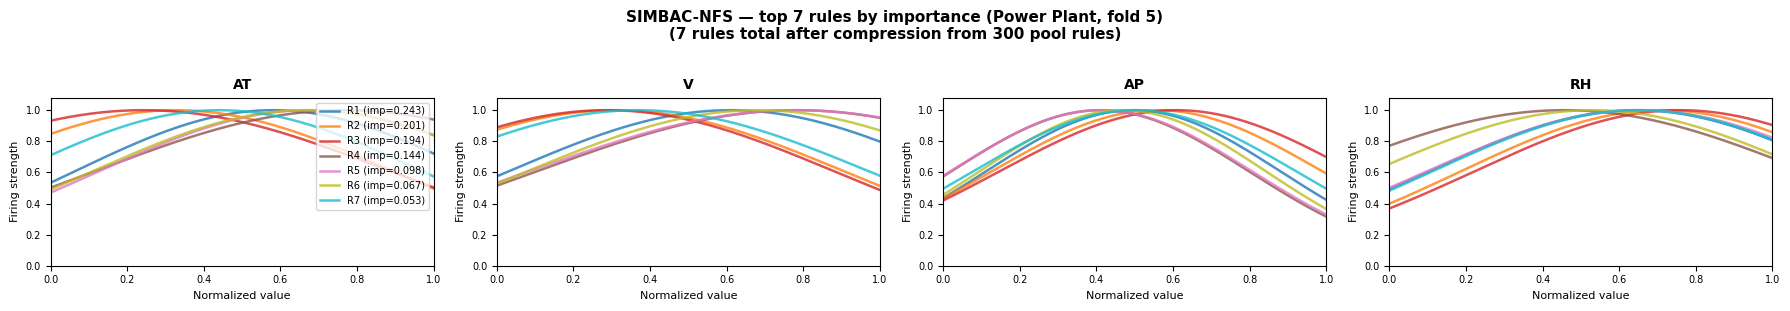

In [9]:
TOP_K  = 7
n_show = min(TOP_K, last_model.n_rules)
importances = last_model.compression_meta_["retained_cluster_importance"]

n_feat = len(last_feat)
ncols  = min(n_feat, 4)
nrows  = (n_feat + ncols - 1) // ncols
colors = plt.cm.tab10(np.linspace(0, 1, n_show))
x_vals = np.linspace(0, 1, 300)

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.0 * nrows), squeeze=False)

for j, fname in enumerate(last_feat):
    ax = axes[j // ncols][j % ncols]
    for r in range(n_show):
        c   = float(last_model.centers_[r, j])
        s   = float(max(last_model.sigmas_[r, j], 1e-3))
        imp = importances[r]
        ax.plot(x_vals, np.exp(-0.5 * ((x_vals - c) / s) ** 2),
                color=colors[r], alpha=0.80, linewidth=1.8,
                label=f"R{r+1} (imp={imp:.3f})")
    ax.set_title(fname, fontsize=10, fontweight="bold")
    ax.set_xlabel("Normalized value", fontsize=8)
    ax.set_ylabel("Firing strength", fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.08)
    ax.tick_params(labelsize=7)
    if j == 0:
        ax.legend(fontsize=7, loc="upper right")

for j in range(n_feat, nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.suptitle(
    f"SIMBAC-NFS — top {n_show} rules by importance (Power Plant, fold 5)\n"
    f"({last_model.n_rules} rules total after compression from "
    f"{last_model.compression_meta_['n_rules_ensemble_total']} pool rules)",
    fontsize=11, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

## 10. Predictions vs Ground Truth (Last Fold)

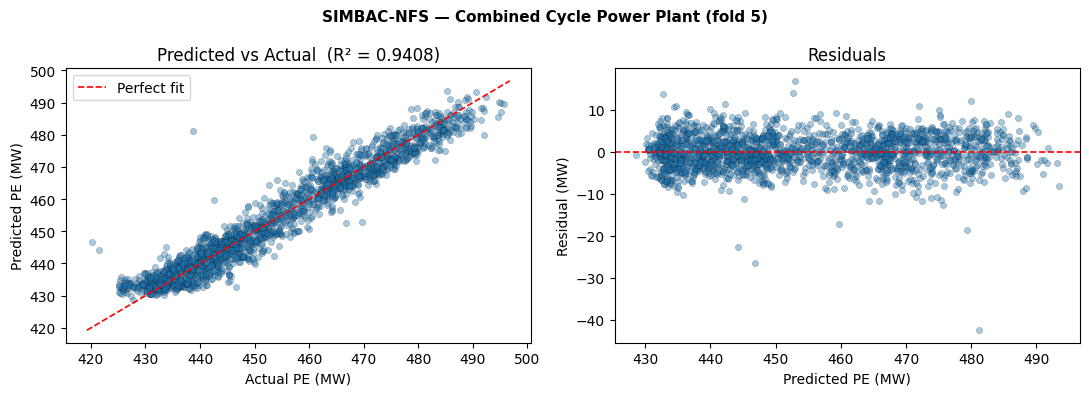

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

r2_last = r2_fn(last_yte, last_ypred)

ax = axes[0]
ax.scatter(last_yte, last_ypred, alpha=0.4, edgecolors="k", linewidths=0.3, s=20)
lim = [min(last_yte.min(), last_ypred.min()) - 1,
       max(last_yte.max(), last_ypred.max()) + 1]
ax.plot(lim, lim, "r--", linewidth=1.2, label="Perfect fit")
ax.set_xlabel("Actual PE (MW)"); ax.set_ylabel("Predicted PE (MW)")
ax.set_title(f"Predicted vs Actual  (R² = {r2_last:.4f})")
ax.legend()

ax = axes[1]
ax.scatter(last_ypred, last_yte - last_ypred,
           alpha=0.4, edgecolors="k", linewidths=0.3, s=20)
ax.axhline(0, color="r", linestyle="--", linewidth=1.2)
ax.set_xlabel("Predicted PE (MW)"); ax.set_ylabel("Residual (MW)")
ax.set_title("Residuals")

plt.suptitle("SIMBAC-NFS — Combined Cycle Power Plant (fold 5)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## 11. Summary

In [11]:
meta        = last_model.compression_meta_
pool_rules  = meta["n_rules_ensemble_total"]
final_rules = meta["n_rules_after"]
m_perf = df_res[["rmse", "mae", "r2"]].mean()
m_interp = df_res[["single_rules", "n_rules", "cr", "pd"]].mean()

print("=" * 50)
print("         SIMBAC-NFS Summary")
print("         Combined Cycle Power Plant (D4)")
print("=" * 50)
print(f"  Protocol : 5-fold CV, T={T}×M={M} GB, τ={tau}")
print("-" * 50)
print(f"  Mean RMSE        : {m_perf['rmse']:>8.4f}")
print(f"  Mean MAE         : {m_perf['mae']:>8.4f}")
print(f"  Mean R\u00b2          : {m_perf['r2']:>8.4f}")
print("-" * 50)
print(f"  Mean single rules: {m_interp['single_rules']:>8.1f}")
print(f"  Mean SIMBAC rules: {m_interp['n_rules']:>8.1f}")
print(f"  Mean compression : {m_interp['cr']:>7.1f}%")
print(f"  Mean part. dist. : {m_interp['pd']:>8.3f}")
print(f"  Pool rules (last fold)  : {pool_rules:>5}")
print(f"  Retained (last fold)    : {final_rules:>5}")
print("=" * 50)
print()
print("Paper reference (Tables II & III, D4):")
print("  RMSE = 4.133   MAE = 3.205   R\u00b2 = 0.9413")
print("  Single Rules = 22\u00b14   SIMBAC Rules = 8\u00b11")
print("  CR = 97.6\u00b10.7%   PD = 0.402\u00b10.008")
print("  Fid = 0.000\u2020 (known anomaly for D4)")

         SIMBAC-NFS Summary
         Combined Cycle Power Plant (D4)
  Protocol : 5-fold CV, T=5×M=3 GB, τ=0.95
--------------------------------------------------
  Mean RMSE        :   4.1330
  Mean MAE         :   3.2044
  Mean R²          :   0.9413
--------------------------------------------------
  Mean single rules:     21.0
  Mean SIMBAC rules:      7.6
  Mean compression :    97.5%
  Mean part. dist. :    0.401
  Pool rules (last fold)  :   300
  Retained (last fold)    :     7

Paper reference (Tables II & III, D4):
  RMSE = 4.133   MAE = 3.205   R² = 0.9413
  Single Rules = 22±4   SIMBAC Rules = 8±1
  CR = 97.6±0.7%   PD = 0.402±0.008
  Fid = 0.000† (known anomaly for D4)


## 12. Rule-Centre Heatmap

Each row is a compressed rule (sorted by importance, most important at top).
Each column is an input feature. Colour encodes the normalised centre position
(0 = feature minimum, 1 = feature maximum); cell text shows the linguistic label
and the numeric centre value.

This is the same visualisation as Figure 5 in the paper.

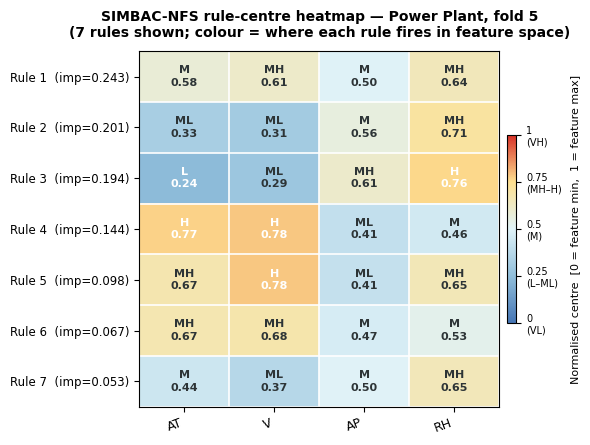

In [12]:
import matplotlib.colors as mcolors

LING_POOL = ["VL", "L", "ML", "M", "MH", "H", "VH"]

def ling_label(v):
    idx = int(round(float(v) * (len(LING_POOL) - 1)))
    return LING_POOL[max(0, min(idx, len(LING_POOL) - 1))]


TOP_K       = 7
n_show      = min(TOP_K, last_model.n_rules)
centers     = last_model.centers_[:n_show]          # (n_show, n_feat)
importances = last_model.compression_meta_["retained_cluster_importance"][:n_show]
feat_labels = last_feat
n_feat      = len(feat_labels)

cmap = mcolors.LinearSegmentedColormap.from_list(
    "bwr_soft",
    ["#4575b4", "#91bfdb", "#e0f3f8", "#fee090", "#d73027"],
    N=256,
)

fig, ax = plt.subplots(figsize=(max(6, n_feat * 1.0), max(3, n_show * 0.65)))

im = ax.imshow(centers, cmap=cmap, vmin=0, vmax=1, aspect="auto")

for r in range(n_show):
    for f in range(n_feat):
        c   = float(centers[r, f])
        lbl = ling_label(c)
        tc  = "white" if (c < 0.25 or c > 0.75) else "#2d3436"
        ax.text(f, r, f"{lbl}\n{c:.2f}",
                ha="center", va="center",
                fontsize=8, color=tc, fontweight="bold",
                linespacing=1.3)

ax.set_xticks(range(n_feat))
ax.set_xticklabels(feat_labels, fontsize=9, rotation=20, ha="right")
ax.set_yticks(range(n_show))
ax.set_yticklabels(
    [f"Rule {r+1}  (imp={importances[r]:.3f})" for r in range(n_show)],
    fontsize=8.5,
)

for x in range(-1, n_feat):
    ax.axvline(x + 0.5, color="white", linewidth=1.2)
for y in range(-1, n_show):
    ax.axhline(y + 0.5, color="white", linewidth=1.2)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Normalised centre  [0 = feature min,  1 = feature max]",
               fontsize=8, labelpad=6)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["0\n(VL)", "0.25\n(L–ML)", "0.5\n(M)",
                     "0.75\n(MH–H)", "1\n(VH)"], fontsize=7)

ax.set_title(
    f"SIMBAC-NFS rule-centre heatmap — Power Plant, fold 5\n"
    f"({n_show} rules shown; colour = where each rule fires in feature space)",
    fontsize=10, fontweight="bold", pad=10,
)
plt.tight_layout()
plt.show()